# What Do You Get When You Pit Lamine Against Saka?
### *Yamal makes you hold your breath. Saka makes you trust the moment. Football needs both.*

**BarcaFutbol Analytics · HackrLife Media LLC · April 2026**

---

This notebook produces all 8 data visualisations from the BarcaFutbol paid player
comparison article on **Lamine Yamal vs Bukayo Saka**, 2025/26 season.

Every chart is built from scratch using Python and matplotlib. All data is sourced
from Sofascore career statistics, verified against source CSVs at time of publication.

### The Analytical Argument

These are not two versions of the same player. They are two answers to the same question:
*what does a world-class wide forward look like when built from the ground up?*

- **Yamal** is the phenomenon — volatile, explosive, statistically unprecedented at 18
- **Saka** is the professional — consistent, reliable, and the product of one of football's
  most sophisticated tactical systems

The charts below build the case from the data, dimension by dimension.

### Charts in This Notebook

| # | Chart | Type |
|---|-------|------|
| 01 | Career Arc | Smoothed line |
| 02 | Full Season Profile | Dual pizza / polar |
| 03 | Attacking Profile | Dual radar |
| 04 | Possession & Creation | Dual radar |
| 05 | Defensive Contribution | Dual radar |
| 06 | Head to Head | Horizontal bar |
| 07 | Creator vs Finisher | Scatter — peer group |
| 08 | xG vs Goals | Scatter — conversion |

---
*Data: Sofascore · All values per 90 minutes · Season: 2025/26 · All competitions*

In [1]:
# Install and import — run this cell first
!pip install matplotlib scipy pandas numpy --quiet

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Wedge, Circle
from matplotlib.lines import Line2D
from scipy.interpolate import make_interp_spline
import numpy as np
import pandas as pd

# ── Colour palette (consistent across all charts) ───────────────────────────
BG='#0d1117'; BG2='#0d1b2a'; BG3='#161b22'
WHITE='#f0f6fc'; GRAY='#8b949e'; GOLD='#EDBB00'
GREEN='#4CAF50'; YELLOW='#ffd60a'; RED='#e63946'
PASS_C='#4CAF50'; DEF_C='#2196F3'; ATK_HI='#ffd60a'; ATK_LO='#e63946'
YAMAL_C='#A50044'   # Barça deep red
SAKA_C ='#f0f6fc'   # clean white

print("Setup complete. Ready to build charts.")

Setup complete. Ready to build charts.


## Load the Master Dataset

All player statistics in a single CSV. Yamal and Saka career data plus 14 peer wide forwards for the scatter plots.

In [1]:
# Load master CSV
# If running locally, adjust the path.
# If running in Colab from the GitHub repo, the path below works directly.
import pandas as pd

df = pd.read_csv('data/barcafutbol_master.csv')

# Split out the key subsets
yamal      = df[df['player'] == 'Lamine Yamal'].sort_values('season')
saka       = df[df['player'] == 'Bukayo Saka'].sort_values('season')
peers_2526 = df[df['season'] == '25/26'].copy()

print(f"Total rows: {len(df)}")
print(f"Yamal seasons: {len(yamal)}")
print(f"Saka seasons:  {len(saka)}")
print(f"Peer group (25/26): {len(peers_2526)} players")
print()
print(peers_2526[['player','team','gls_90','xa_90','xg_90']].to_string(index=False))

Total rows: 25
Yamal seasons: 4
Saka seasons:  8
Peer group (25/26): 15 players

         player          team  gls_90  xa_90  xg_90
   Lamine Yamal     Barcelona     0.6   0.33   0.41
    Bukayo Saka       Arsenal     0.3   0.25   0.28
  Kylian Mbappé   Real Madrid     1.1   0.24   0.90
     Harry Kane Bayern Munich     1.4   0.13   0.90
       Raphinha     Barcelona     0.8   0.31   0.52
Ousmane Dembélé           PSG     0.8   0.29   0.51
  Michael Olise Bayern Munich     0.5   0.52   0.37
      Luis Díaz Bayern Munich     0.6   0.25   0.47
  Mohamed Salah     Liverpool     0.3   0.27   0.38
Marcus Rashford     Barcelona     0.5   0.24   0.31
  Kvaratskhelia           PSG     0.5   0.24   0.33
Bradley Barcola           PSG     0.5   0.21   0.49
     Leroy Sané   Galatasaray     0.2   0.24   0.21
  Florian Wirtz     Liverpool     0.2   0.24   0.23
    Désiré Doué           PSG     0.5   0.25   0.43


---
## Chart 01 · Career Arc

**What this shows:** Goals + Assists per 90 (GI/90) across every career season
for both players, smoothed with a cubic spline interpolation.

**What to look for:**
- Saka's steady seven-season climb to a peak of **0.9 GI/90** at Age 23
- Yamal's vertical spike to **1.0 GI/90** at Age 18 — statistically unprecedented
- Saka's current dip to **0.4 GI/90** at Age 24 — the most important unanswered question

The spline smoothing makes the trajectory readable across different data densities
(Yamal has 4 seasons, Saka has 8).

**Key analytical insight:** Yamal at 18 already matches Saka's career peak.
The question is whether that's a ceiling or a launch pad.

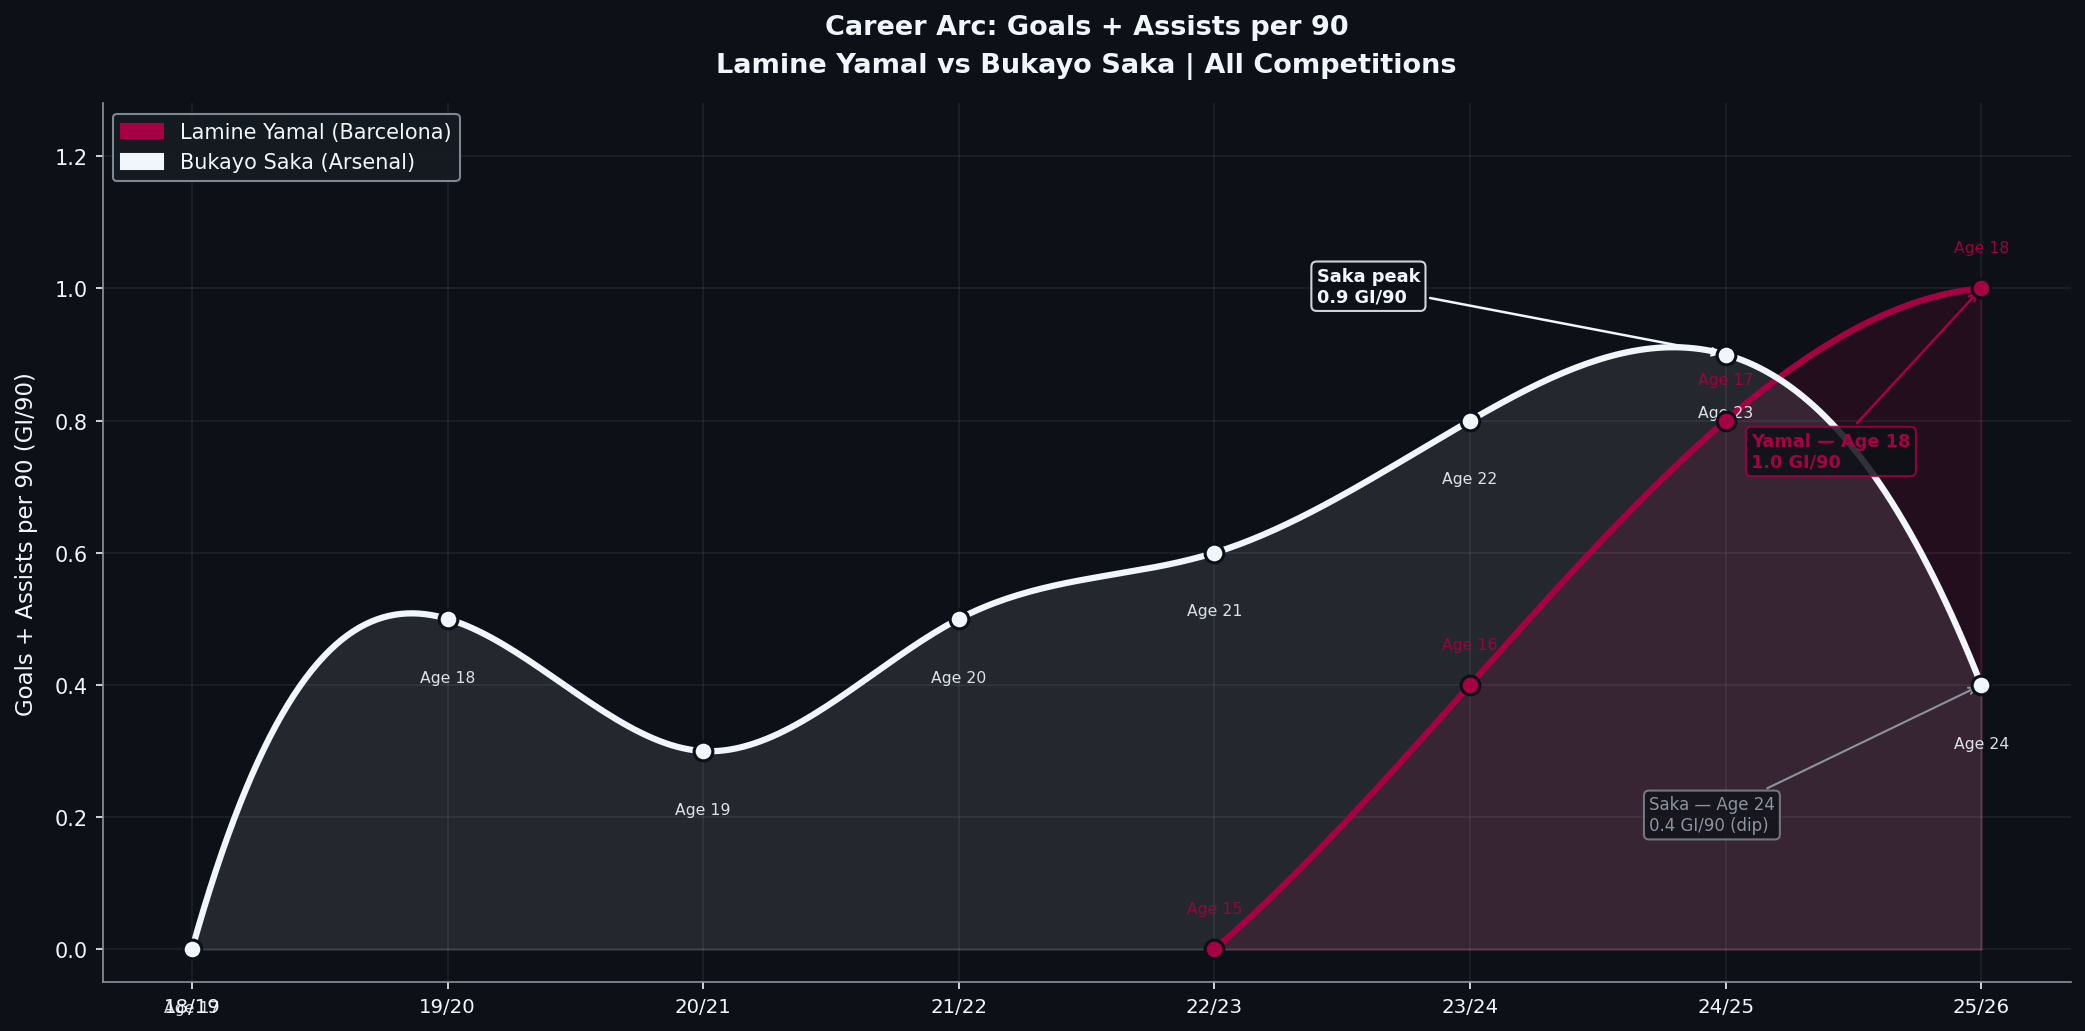

In [1]:
# Chart 01 — Career Arc
# Cubic spline smoothing over per-season GI/90 datapoints

yamal_seasons = df[df['player']=='Lamine Yamal'].sort_values('season')
saka_seasons  = df[df['player']=='Bukayo Saka'].sort_values('season')

# Map season strings to numeric midpoints for plotting
season_map = {'18/19':2018.5,'19/20':2019.5,'20/21':2020.5,'21/22':2021.5,
              '22/23':2022.5,'23/24':2023.5,'24/25':2024.5,'25/26':2025.5}

yamal_x  = [season_map[s] for s in yamal_seasons['season']]
yamal_gi = list(yamal_seasons['gi_90'])
yamal_age= list(yamal_seasons['age'])

saka_x   = [season_map[s] for s in saka_seasons['season']]
saka_gi  = list(saka_seasons['gi_90'].fillna(0))
saka_age = list(saka_seasons['age'])

def smooth(x, y):
    """Cubic spline — requires at least 4 data points."""
    xs = np.linspace(min(x), max(x), 300)
    return xs, make_interp_spline(x, y, k=min(3, len(x)-1))(xs)

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

yx, yy = smooth(yamal_x, yamal_gi)
sx, sy = smooth(saka_x,  saka_gi)

ax.plot(yx, yy, color=YAMAL_C, linewidth=3, zorder=3)
ax.fill_between(yx, yy, alpha=0.15, color=YAMAL_C)
ax.plot(sx, sy, color=SAKA_C,  linewidth=3, zorder=3)
ax.fill_between(sx, sy, alpha=0.10, color=SAKA_C)

for x, y, age in zip(yamal_x, yamal_gi, yamal_age):
    ax.plot(x, y, 'o', color=YAMAL_C, markersize=9,
            markeredgecolor=BG, markeredgewidth=1.5, zorder=5)
    ax.text(x, y+0.055, f'Age {int(age)}', color=YAMAL_C,
            fontsize=7.5, ha='center', alpha=0.9)

for x, y, age in zip(saka_x, saka_gi, saka_age):
    ax.plot(x, y, 'o', color=SAKA_C, markersize=9,
            markeredgecolor=BG, markeredgewidth=1.5, zorder=5)
    ax.text(x, y-0.095, f'Age {int(age)}', color=SAKA_C,
            fontsize=7.5, ha='center', alpha=0.9)

ax.annotate('Saka peak\n0.9 GI/90', xy=(2024.5, 0.9), xytext=(2022.9, 0.98),
    color=SAKA_C, fontsize=8.5, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=SAKA_C, lw=1.2),
    bbox=dict(boxstyle='round,pad=0.3', facecolor=BG, edgecolor=SAKA_C, alpha=0.85))
ax.annotate('Yamal — Age 18\n1.0 GI/90', xy=(2025.5, 1.0), xytext=(2024.6, 0.73),
    color=YAMAL_C, fontsize=8.5, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=YAMAL_C, lw=1.2),
    bbox=dict(boxstyle='round,pad=0.3', facecolor=BG, edgecolor=YAMAL_C, alpha=0.85))
ax.annotate('Saka — Age 24\n0.4 GI/90 (dip)', xy=(2025.5, 0.4), xytext=(2024.2, 0.18),
    color=GRAY, fontsize=8,
    arrowprops=dict(arrowstyle='->', color=GRAY, lw=1.0),
    bbox=dict(boxstyle='round,pad=0.3', facecolor=BG, edgecolor=GRAY, alpha=0.75))

ax.set_xticks([season_map[s] for s in saka_seasons['season']])
ax.set_xticklabels(list(saka_seasons['season']), color=WHITE, fontsize=9.5)
ax.set_ylabel('Goals + Assists per 90 (GI/90)', color=WHITE, fontsize=11, labelpad=8)
ax.tick_params(colors=WHITE)
ax.spines['bottom'].set_color(GRAY); ax.spines['left'].set_color(GRAY)
ax.spines['top'].set_visible(False);  ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.07, color=WHITE); ax.set_ylim(-0.05, 1.28)
ax.legend(handles=[
    mpatches.Patch(color=YAMAL_C, label='Lamine Yamal (Barcelona)'),
    mpatches.Patch(color=SAKA_C,  label='Bukayo Saka (Arsenal)')],
    loc='upper left', facecolor=BG3, edgecolor=GRAY,
    labelcolor=WHITE, fontsize=10, framealpha=0.9)
ax.set_title('Career Arc: Goals + Assists per 90\n'
             'Lamine Yamal vs Bukayo Saka | All Competitions',
             color=WHITE, fontsize=13, fontweight='bold', pad=15, linespacing=1.6)
plt.tight_layout()
plt.show()

---
## Radar Chart Helper Function

The next three charts (Attacking, Possession, Defensive) all use the same
dual-radar function. We define it once here.

**How it works:**
- Both players are plotted on the same polar axes
- Values are percentile ranks (0–100) estimated against European wide-forward peers
- Outer dotted ring = 100th percentile boundary
- Filled markers at each vertex coloured by player
- The further a vertex extends toward the outer ring, the higher the percentile

In [1]:
# Dual radar helper — used for charts 03, 04, 05

def dual_radar(cats, y_vals, s_vals, title):
    """
    Build and display a dual-player radar chart.

    Parameters
    ----------
    cats   : list[str]  — metric labels, use \\n for line breaks
    y_vals : list[int]  — Yamal percentile values 0-100
    s_vals : list[int]  — Saka  percentile values 0-100
    title  : str        — chart title
    """
    n = len(cats)
    angles   = np.linspace(0, 2*np.pi, n, endpoint=False).tolist()
    angles_c = angles + angles[:1]
    yp = y_vals + y_vals[:1]
    sp = s_vals + s_vals[:1]

    fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
    fig.patch.set_facecolor(BG2); ax.set_facecolor(BG2)

    # Interior grid rings
    for lv in [20, 40, 60, 80]:
        ax.plot(angles_c, [lv]*(n+1), color=WHITE, alpha=0.09,
                linewidth=0.6, linestyle='--')
    # Outer boundary ring — dotted white
    ax.plot(angles_c, [100]*(n+1), color=WHITE, alpha=0.50,
            linewidth=1.4, linestyle=(0, (4, 3)))
    # Spokes
    for a in angles:
        ax.plot([a, a], [0, 100], color=WHITE, alpha=0.08, linewidth=0.5)

    # Yamal
    ax.fill(angles_c, yp, color=YAMAL_C, alpha=0.22)
    ax.plot(angles_c, yp, color=YAMAL_C, linewidth=2.5)
    for a, v in zip(angles, y_vals):
        ax.plot(a, v, 'o', color=YAMAL_C, markersize=8,
                markeredgecolor=BG2, markeredgewidth=1.5, zorder=5)

    # Saka
    ax.fill(angles_c, sp, color=SAKA_C, alpha=0.12)
    ax.plot(angles_c, sp, color=SAKA_C, linewidth=2.5)
    for a, v in zip(angles, s_vals):
        ax.plot(a, v, 'o', color=SAKA_C, markersize=8,
                markeredgecolor=BG2, markeredgewidth=1.5, zorder=5)

    # Category labels
    for a, cat in zip(angles, cats):
        ax.text(a, 122, cat, ha='center', va='center',
                fontsize=9.5, color=WHITE, fontweight='bold',
                multialignment='center')

    ax.set_ylim(0, 130); ax.set_yticks([]); ax.set_xticks([])
    ax.spines['polar'].set_visible(False); ax.grid(False)

    ax.legend(handles=[
        Line2D([0],[0], marker='o', color=YAMAL_C, label='Lamine Yamal (Barcelona)',
               markerfacecolor=YAMAL_C, markeredgecolor=BG2, markersize=9, linewidth=2.5),
        Line2D([0],[0], marker='o', color=SAKA_C,  label='Bukayo Saka (Arsenal)',
               markerfacecolor=SAKA_C,  markeredgecolor=BG2, markersize=9, linewidth=2.5),
    ], loc='lower right', bbox_to_anchor=(1.32, -0.05), fontsize=9.5,
       facecolor=BG3, edgecolor=GRAY, labelcolor=WHITE, framealpha=0.9)

    ax.set_title(title, color=WHITE, fontsize=11, fontweight='bold',
                 pad=32, linespacing=1.6)
    plt.tight_layout()
    plt.show()

print("dual_radar() function defined — ready for charts 03, 04, 05")

dual_radar() function defined — ready for charts 03, 04, 05


---
## Chart 03 · Attacking Profile

**6 metrics, estimated percentile vs European wide forwards, 2025/26.**

| Metric | Yamal | Saka |
|--------|-------|------|
| Goals /90 | 0.60 (88th pct) | 0.30 (62nd) |
| xG /90 | 0.41 (82nd) | 0.28 (60th) |
| Shots /90 | 4.0 (92nd) | 3.0 (74th) |
| Shots on Target /90 | 1.4 (75th) | 1.4 (65th) |
| Big Chances Scored | 72nd | 68th |
| Shot Creating Actions | 5.3 (90th) | 1.9 (72nd) |

**Key insight:** Yamal's shot volume (92nd percentile) is the most extreme number
in this comparison — he generates a shooting opportunity every ~17 minutes.
Saka's profile is more measured but still elite across all six dimensions.

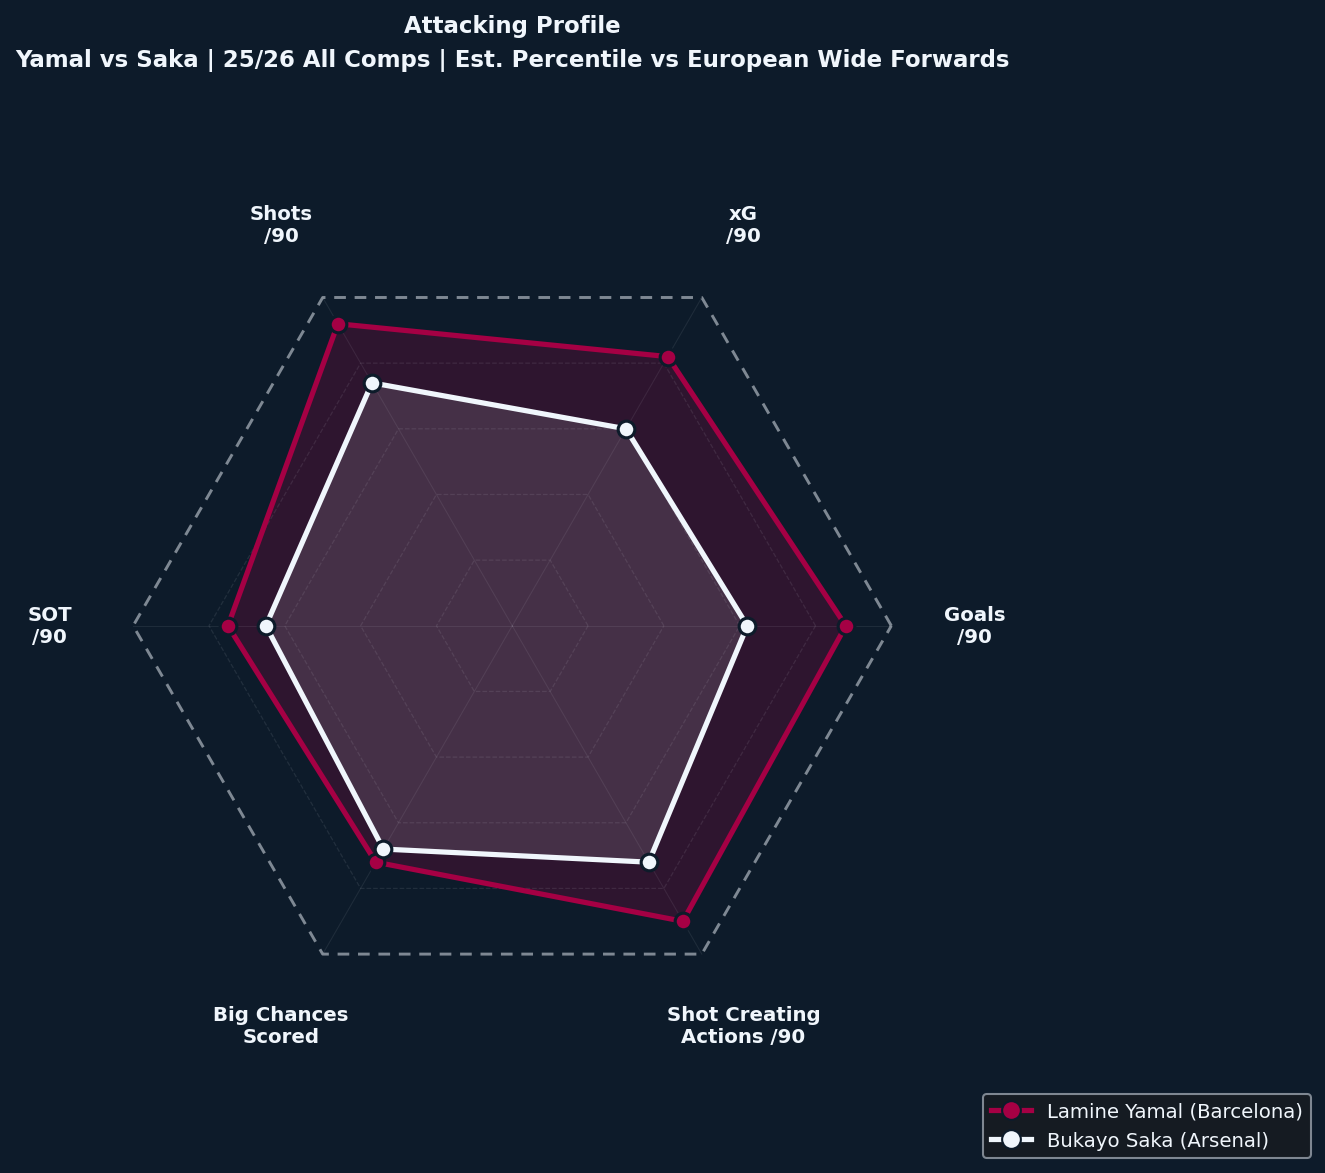

In [1]:
# Chart 03 — Attacking Profile
# Call the dual_radar helper with attacking metrics and verified percentile estimates

dual_radar(
    cats=[
        'Goals\n/90', 'xG\n/90', 'Shots\n/90',
        'SOT\n/90', 'Big Chances\nScored', 'Shot Creating\nActions /90'
    ],
    y_vals=[88, 82, 92, 75, 72, 90],   # Yamal — estimated pct vs European wide fwds
    s_vals=[62, 60, 74, 65, 68, 72],   # Saka  — estimated pct vs PL wide fwds
    title='Attacking Profile\nYamal vs Saka | 25/26 All Comps | '
          'Est. Percentile vs European Wide Forwards'
)

---
## Chart 04 · Possession & Creation Profile

| Metric | Yamal | Saka |
|--------|-------|------|
| Pass Accuracy % | 81.3 (58th pct) | 78.6 (50th) |
| Key Passes /90 | 2.8 (85th) | 2.5 (78th) |
| Cross Accuracy % | 21.3 (22nd) | 31.3 (52nd) |
| Shot Creating Actions /90 | 5.3 (90th) | 1.9 (48th) |
| Dribble Success /90 | 5.3 (88th) | 1.9 (45th) |
| Progressive Actions /90 | 87th | 52nd |

**Key insight:** The cross accuracy gap is the most tactically significant number here.
Yamal (22nd percentile) crosses at maximum frequency regardless of the situation.
Saka (52nd percentile) selects his delivery moments — his teammates can time their runs
to his delivery because it arrives more reliably.

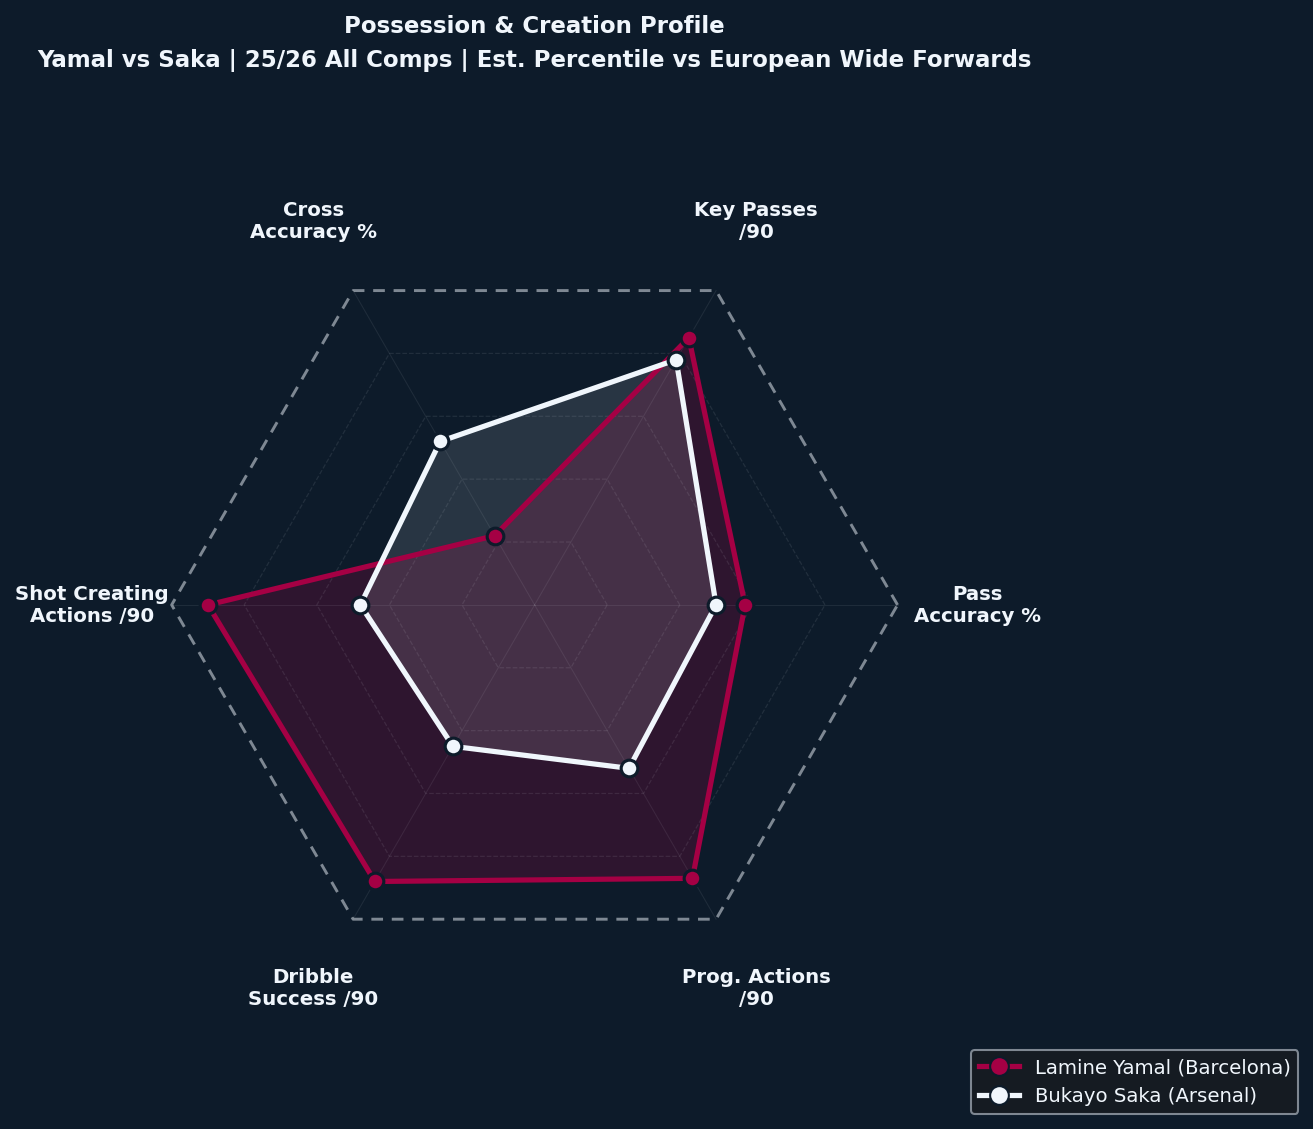

In [1]:
# Chart 04 — Possession & Creation Profile

dual_radar(
    cats=[
        'Pass\nAccuracy %', 'Key Passes\n/90', 'Cross\nAccuracy %',
        'Shot Creating\nActions /90', 'Dribble\nSuccess /90', 'Prog. Actions\n/90'
    ],
    y_vals=[58, 85, 22, 90, 88, 87],
    s_vals=[50, 78, 52, 48, 45, 52],
    title='Possession & Creation Profile\nYamal vs Saka | 25/26 All Comps | '
          'Est. Percentile vs European Wide Forwards'
)

---
## Chart 05 · Defensive Contribution

| Metric | Yamal | Saka |
|--------|-------|------|
| Tackles /90 | 1.4 (55th pct) | 1.4 (55th) |
| Interceptions /90 | 0.4 (42nd) | 0.7 (62nd) |
| Rarely Dribbled Past | 0.6 (55th) | 0.8 (48th) |
| Clearances /90 | 0.2 (28th) | 0.3 (32nd) |
| Discipline (low YC) | 0.2 YC (72nd) | 0.03 YC (88th) |
| Defensive Work Rate | 50th | 72nd |

**Key insight:** Saka's yellow card rate of 0.03 per 90 in the Premier League
is the 88th percentile — he presses and tackles at high intensity without the
disciplinary risk that forces managers to manage his aggression.
Yamal's defensive contribution has declined as Barcelona have conserved him.

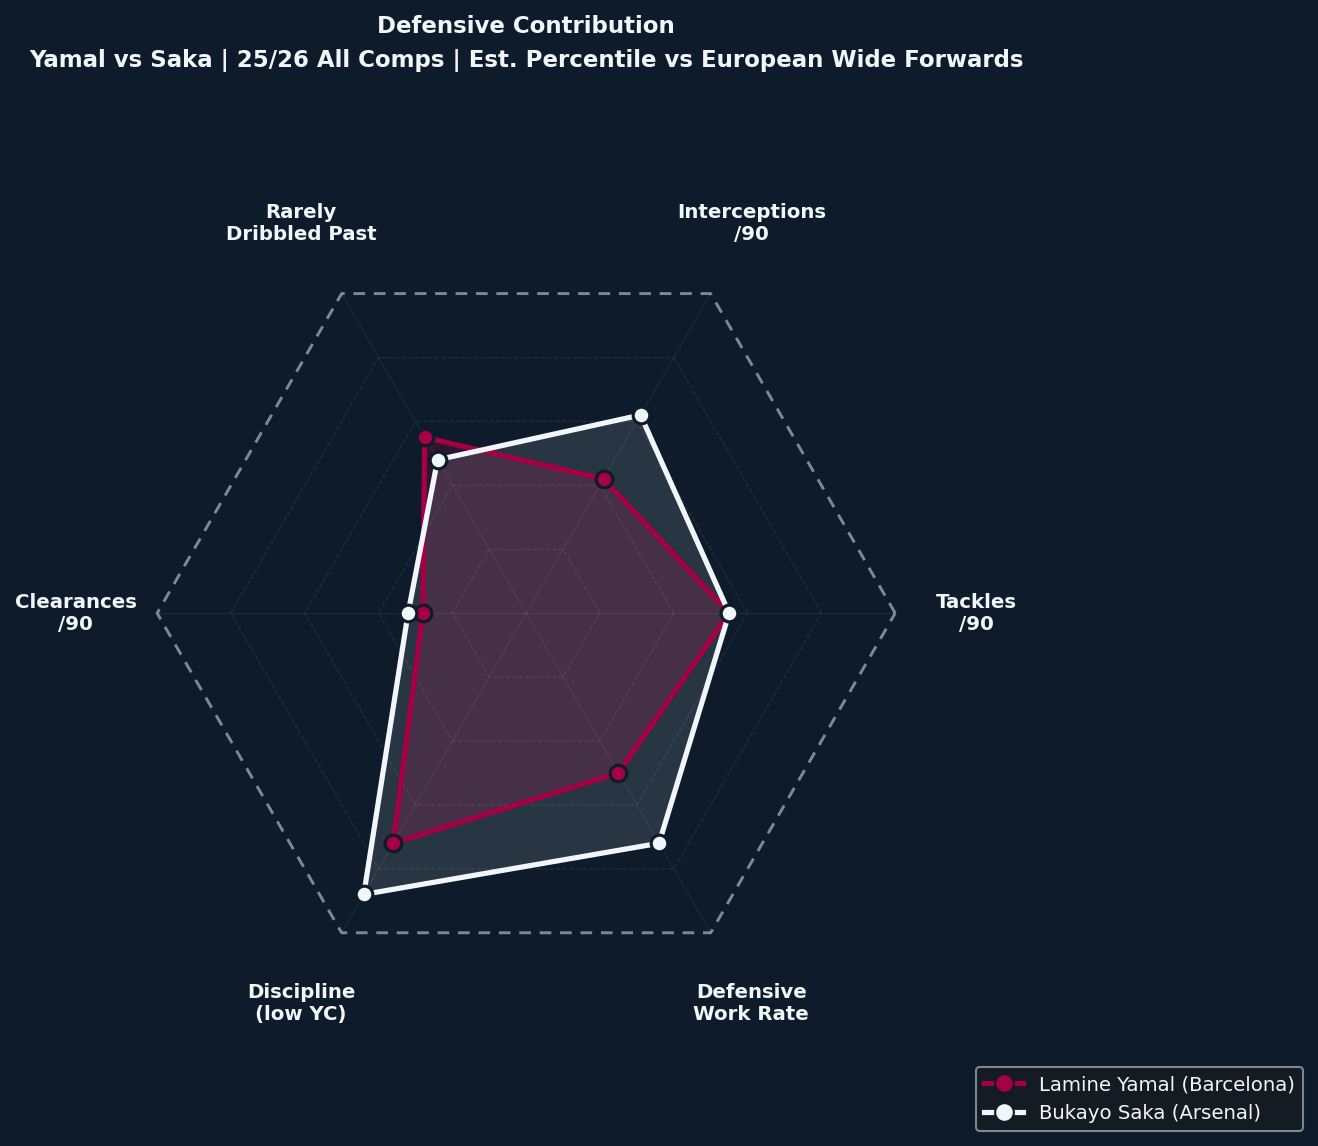

In [1]:
# Chart 05 — Defensive Contribution

dual_radar(
    cats=[
        'Tackles\n/90', 'Interceptions\n/90', 'Rarely\nDribbled Past',
        'Clearances\n/90', 'Discipline\n(low YC)', 'Defensive\nWork Rate'
    ],
    y_vals=[55, 42, 55, 28, 72, 50],
    s_vals=[55, 62, 48, 32, 88, 72],
    title='Defensive Contribution\nYamal vs Saka | 25/26 All Comps | '
          'Est. Percentile vs European Wide Forwards'
)

---
## Chart 02 · Full Season Profile — Dual Pizza

The complete 10-metric season profile for both players, percentile-ranked.
This chart gives the 30,000-foot view before the attribute-by-attribute radars.

**Reading it:** Each slice extends outward proportionally to the percentile rank.
Gold = elite (≥70th), Yellow = average (40–69th), Red = below average (<40th).

**The clearest single contrast:** Yamal's Cross Accuracy (22nd pct, red, collapses inward)
vs Saka's (52nd pct, yellow, extends outward). Both are wide forwards who cross —
but Saka selects his moments. Yamal attacks regardless of the situation.

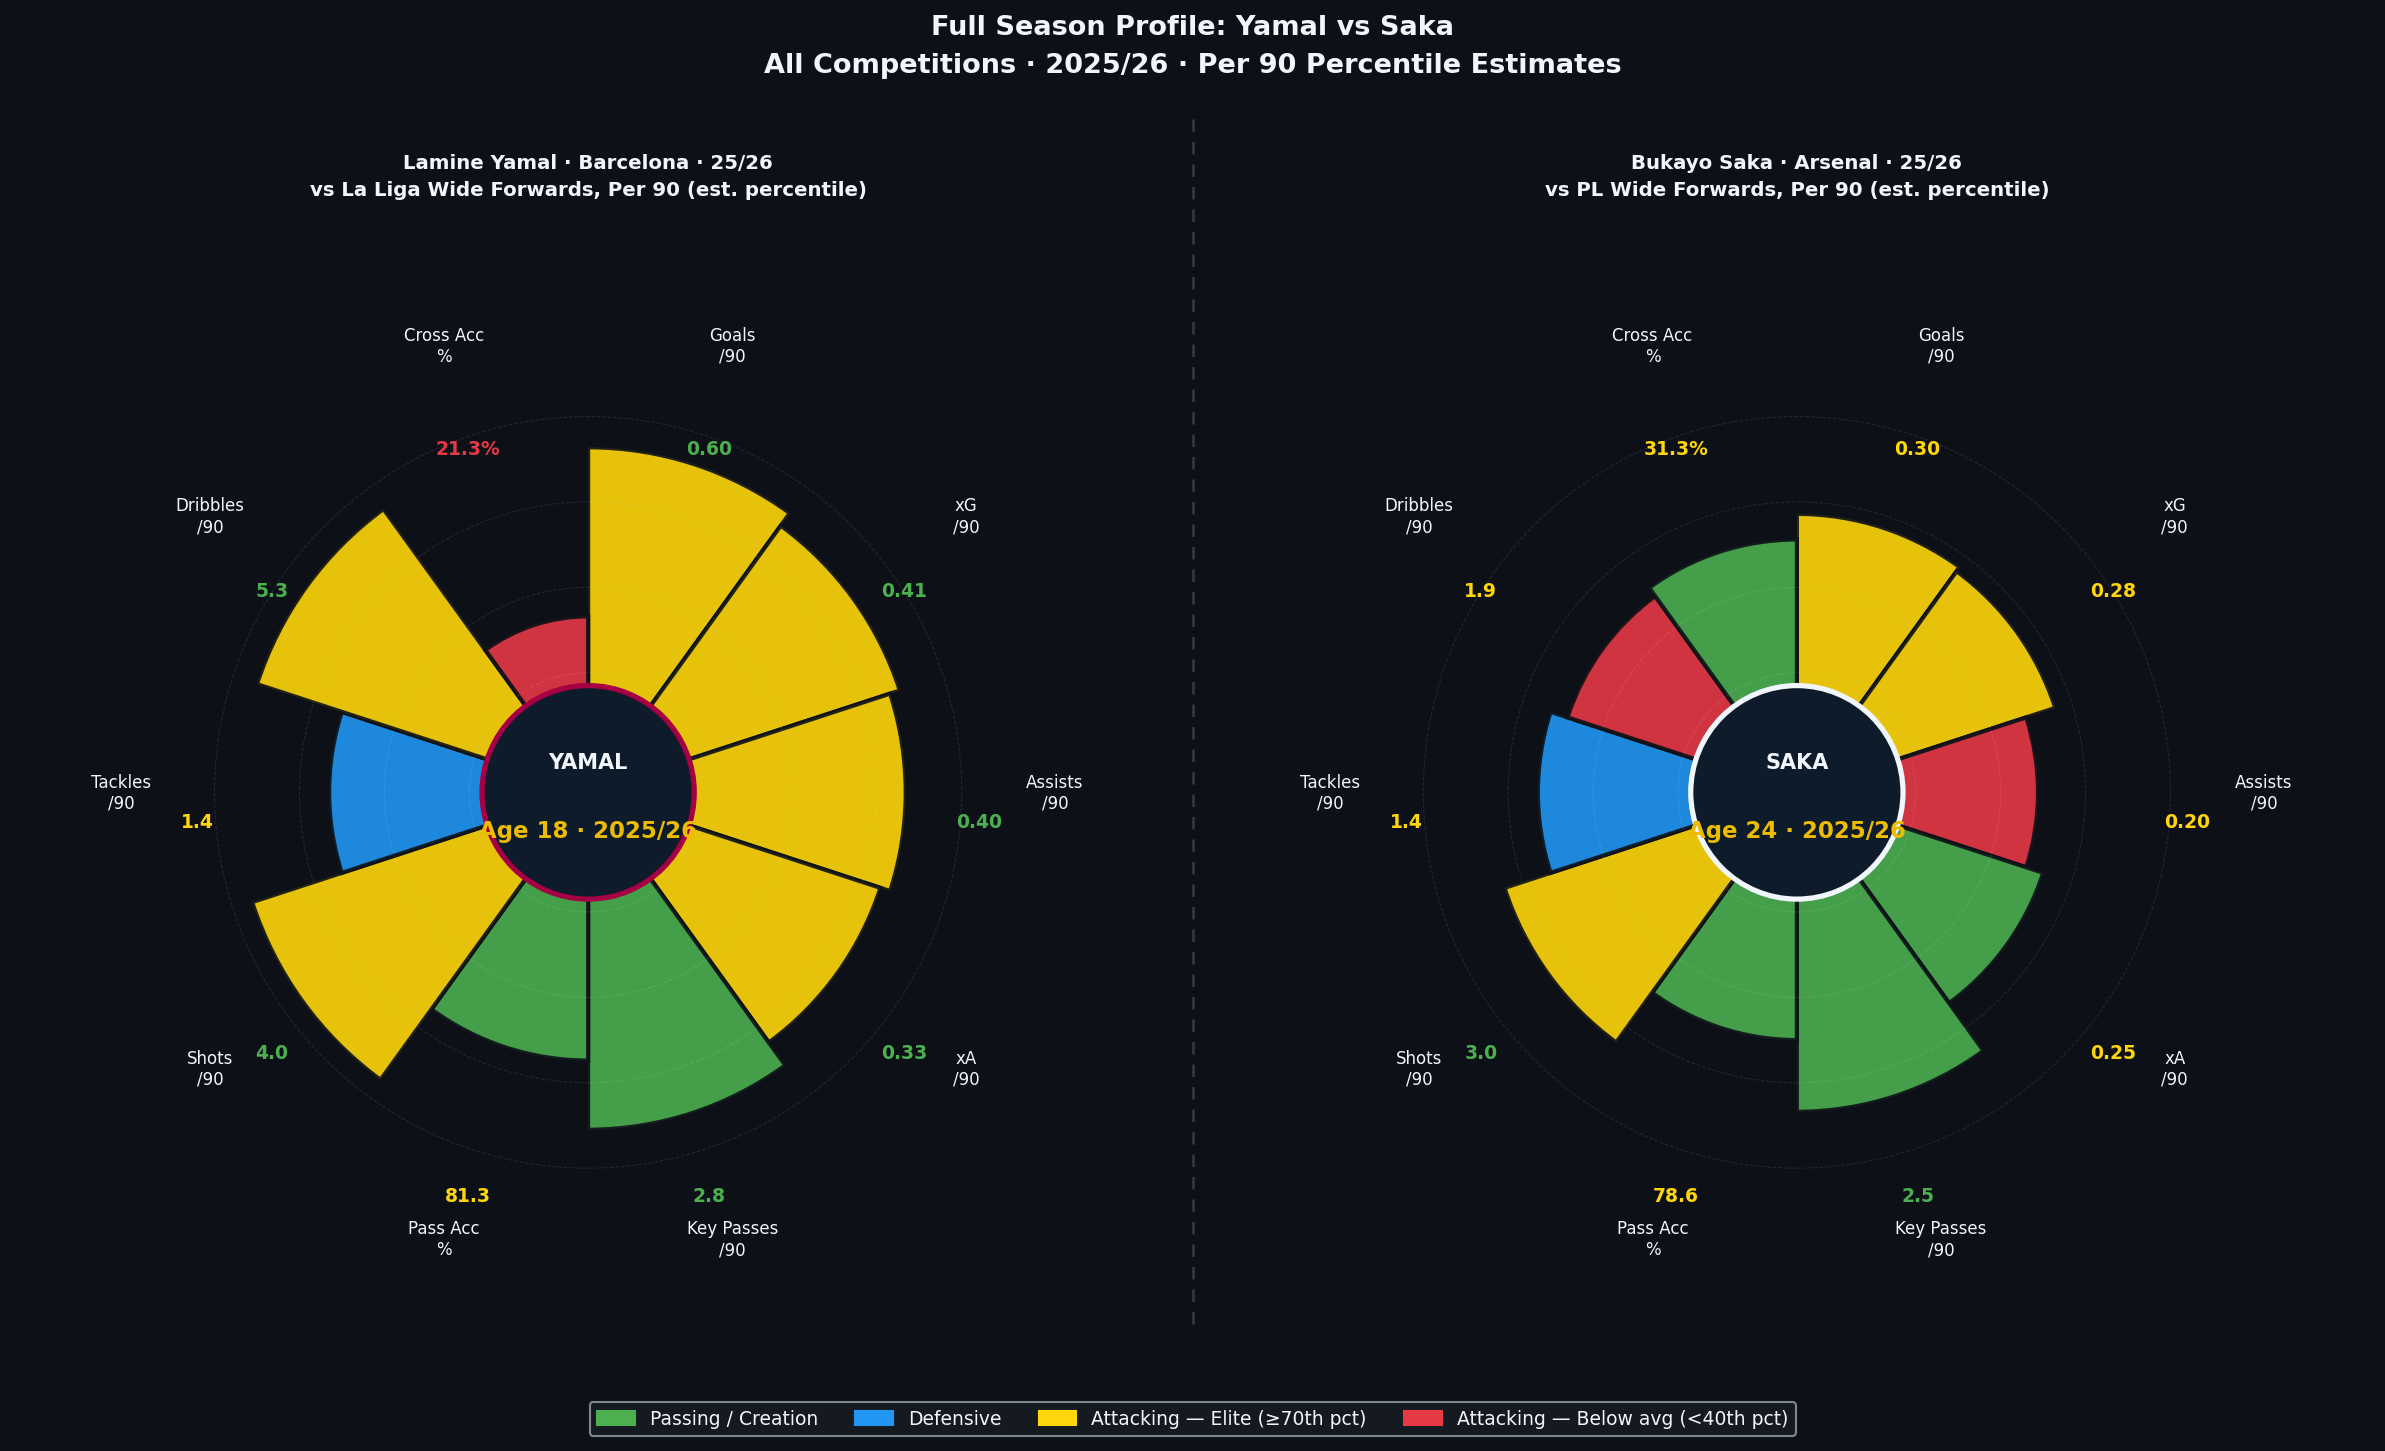

In [1]:
# Chart 02 — Full Season Profile Dual Pizza
# Each slice size = percentile rank (0-100) vs position peers
# Colour = quality tier: Gold ≥70th · Yellow 40-69th · Red <40th

from matplotlib.patches import Wedge, Circle
import matplotlib.patches as mpatches

cat_colors = {'passing': PASS_C, 'defensive': DEF_C,
              'attacking_high': ATK_HI, 'attacking': ATK_LO}

yamal_metrics = [
    # (label, raw_value_display, percentile_0_to_100, category)
    ('Goals\n/90',      '0.60',  88, 'attacking_high'),
    ('xG\n/90',         '0.41',  82, 'attacking_high'),
    ('Assists\n/90',    '0.40',  78, 'attacking_high'),
    ('xA\n/90',         '0.33',  74, 'attacking_high'),
    ('Key Passes\n/90', '2.8',   85, 'passing'),
    ('Pass Acc\n%',     '81.3',  58, 'passing'),
    ('Shots\n/90',      '4.0',   92, 'attacking_high'),
    ('Tackles\n/90',    '1.4',   55, 'defensive'),
    ('Dribbles\n/90',   '5.3',   90, 'attacking_high'),
    ('Cross Acc\n%',    '21.3%', 22, 'attacking'),
]
saka_metrics = [
    ('Goals\n/90',      '0.30',  62, 'attacking_high'),
    ('xG\n/90',         '0.28',  60, 'attacking_high'),
    ('Assists\n/90',    '0.20',  48, 'attacking'),
    ('xA\n/90',         '0.25',  55, 'passing'),
    ('Key Passes\n/90', '2.5',   78, 'passing'),
    ('Pass Acc\n%',     '78.6',  50, 'passing'),
    ('Shots\n/90',      '3.0',   74, 'attacking_high'),
    ('Tackles\n/90',    '1.4',   55, 'defensive'),
    ('Dribbles\n/90',   '1.9',   48, 'attacking'),
    ('Cross Acc\n%',    '31.3%', 52, 'passing'),
]

def draw_pizza(ax, metrics, name, rating_str, edge_color, subtitle):
    n = len(metrics)
    for i, (label, display, raw, cat) in enumerate(metrics):
        t1 = 90 - i*(360/n); t2 = t1 - (360/n)
        ext = min(raw/100, 1.0)
        ax.add_patch(Wedge((0,0), r=0.28+ext*0.60, theta1=t2, theta2=t1,
                           facecolor=cat_colors[cat], edgecolor=BG,
                           linewidth=2, alpha=0.90))
        ar = np.radians((t1+t2)/2)
        ax.text(1.10*np.cos(ar), 1.10*np.sin(ar), label,
                ha='center', va='center', fontsize=8, color=WHITE, multialignment='center')
        vc = GREEN if raw>=70 else (YELLOW if raw>=40 else RED)
        ax.text(0.92*np.cos(ar), 0.92*np.sin(ar)-0.07, display,
                ha='center', va='center', fontsize=9, color=vc, fontweight='bold')
    for r in [0.28, 0.48, 0.68, 0.88]:
        ax.add_patch(Circle((0,0), r, fill=False, color=WHITE,
                            alpha=0.10, linewidth=0.5, linestyle='--'))
    ax.add_patch(Circle((0,0), 0.25, facecolor=BG2, edgecolor=edge_color, linewidth=2.5))
    ax.text(0,  0.07, name,        ha='center', va='center', fontsize=10, color=WHITE, fontweight='bold')
    ax.text(0, -0.09, rating_str, ha='center', va='center', fontsize=11, color=GOLD,  fontweight='bold')
    ax.set_xlim(-1.35, 1.35); ax.set_ylim(-1.35, 1.35); ax.axis('off')
    ax.set_title(subtitle, color=WHITE, fontsize=9.5, fontweight='bold', pad=10, linespacing=1.5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 9))
fig.patch.set_facecolor(BG); ax1.set_facecolor(BG); ax2.set_facecolor(BG)

draw_pizza(ax1, yamal_metrics, 'YAMAL', 'Age 18 · 2025/26', YAMAL_C,
    'Lamine Yamal · Barcelona · 25/26\nvs La Liga Wide Forwards, Per 90 (est. percentile)')
draw_pizza(ax2, saka_metrics,  'SAKA',  'Age 24 · 2025/26', SAKA_C,
    'Bukayo Saka · Arsenal · 25/26\nvs PL Wide Forwards, Per 90 (est. percentile)')

fig.add_artist(plt.Line2D([0.5, 0.5], [0.05, 0.95], transform=fig.transFigure,
               color=WHITE, alpha=0.18, linewidth=1.2, linestyle=(0, (5, 4))))

fig.legend(handles=[
    mpatches.Patch(color=PASS_C, label='Passing / Creation'),
    mpatches.Patch(color=DEF_C,  label='Defensive'),
    mpatches.Patch(color=ATK_HI, label='Attacking — Elite (≥70th pct)'),
    mpatches.Patch(color=ATK_LO, label='Attacking — Below avg (<40th pct)'),
], loc='lower center', ncol=4, fontsize=9, facecolor=BG3, edgecolor=GRAY,
   labelcolor=WHITE, framealpha=0.9, bbox_to_anchor=(0.5, -0.04))

fig.suptitle('Full Season Profile: Yamal vs Saka\n'
             'All Competitions · 2025/26 · Per 90 Percentile Estimates',
             color=WHITE, fontsize=13, fontweight='bold', y=1.02, linespacing=1.6)
plt.tight_layout(w_pad=3)
plt.show()

---
## Chart 06 · Head to Head — Key Metrics Per 90

Direct comparison across 10 metrics. Bars are normalised to 0–100 scale
for visual comparison; the raw per-90 values are displayed at each bar end.

**Yamal leads:** Goals, xG, Assists, xA, Key Passes, Shots, Dribbles (7 of 10)
**Saka leads:** Pass Accuracy, Cross Accuracy (2 of 10)

The two metrics Saka wins — precision metrics — are the ones that make a team's
attacking system structurally reliable. Yamal's seven wins are the ones that
make a game feel different when he is on the pitch.

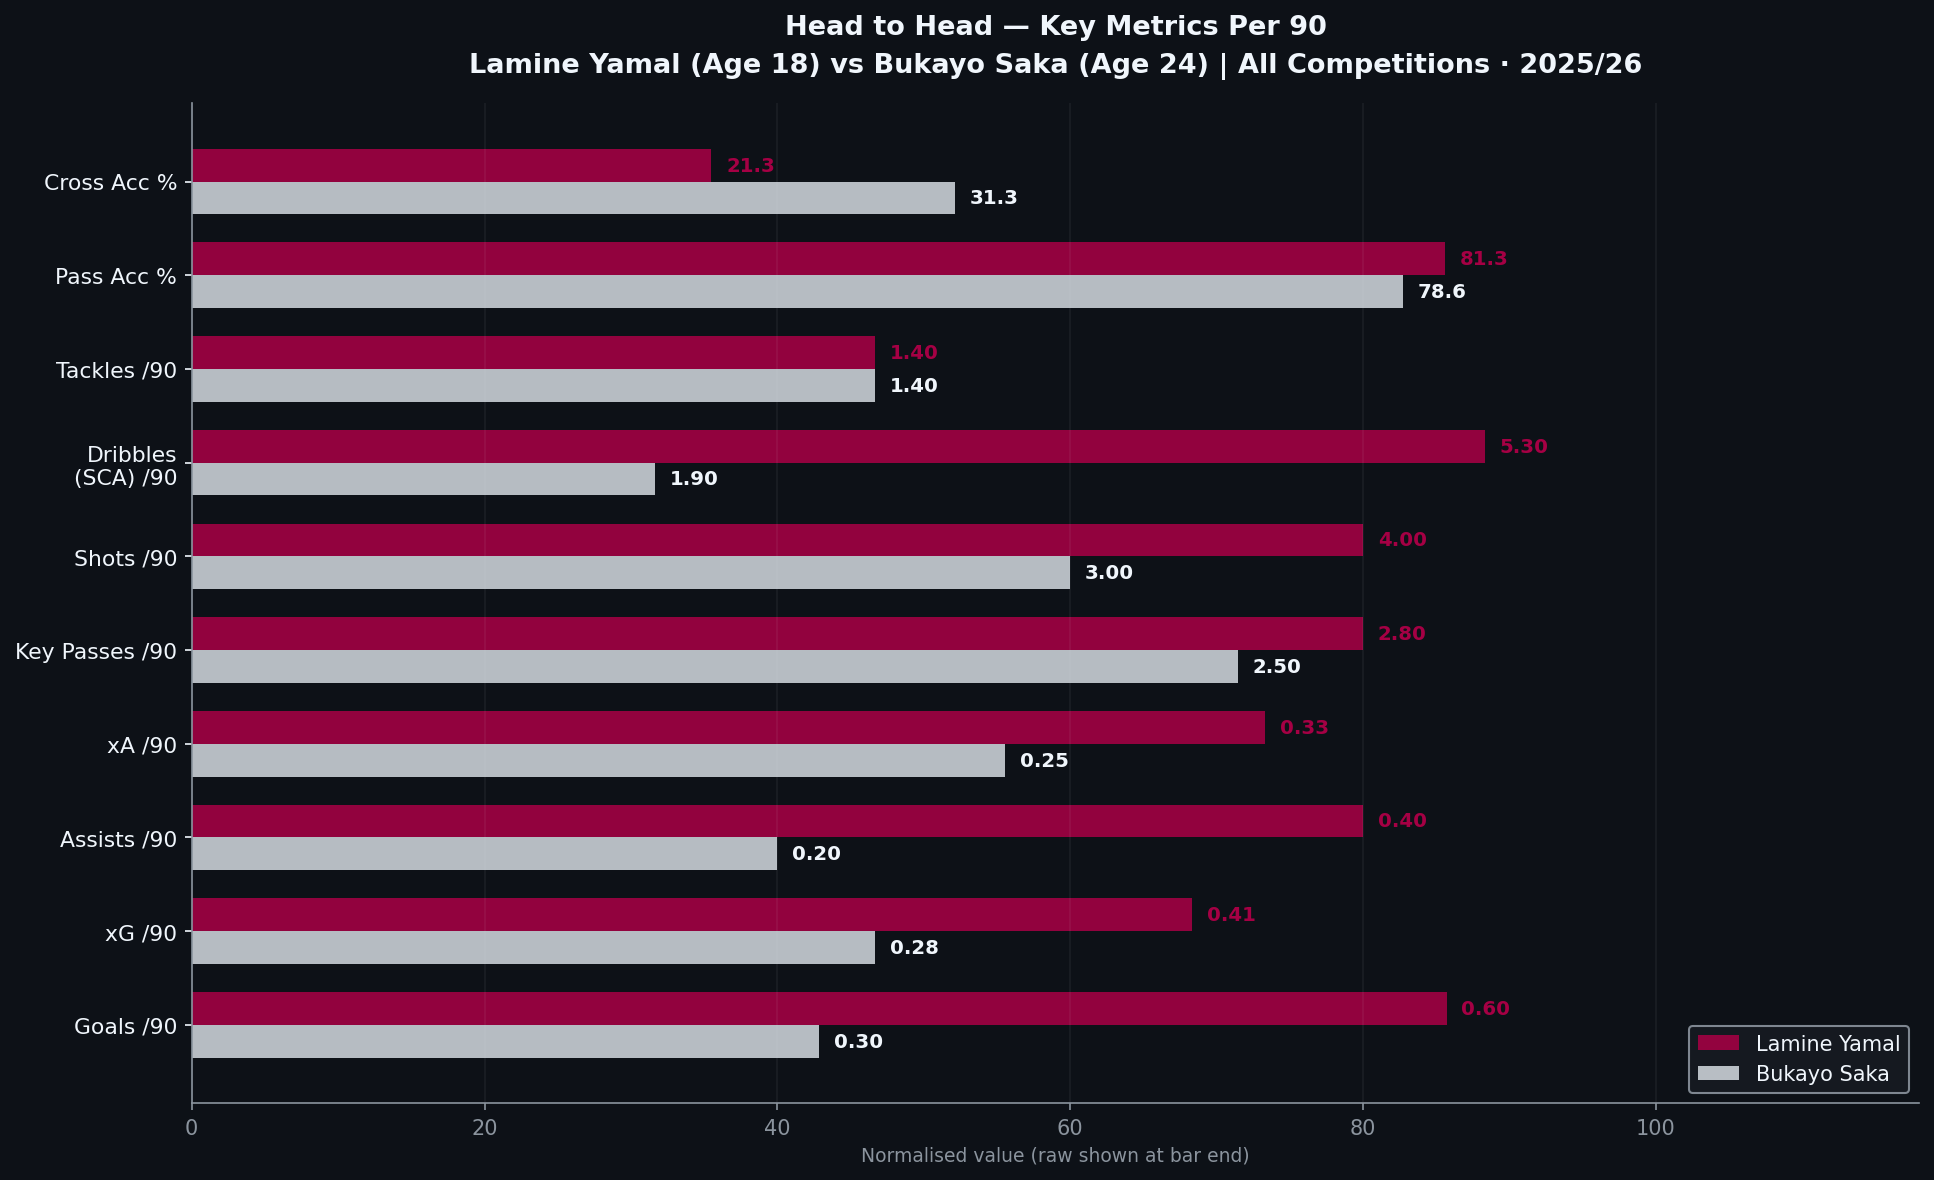

In [1]:
# Chart 06 — Head to Head Bar Chart
# Bars normalised to 0-100 scale for visual comparison
# Raw per-90 values shown at bar end

metrics   = ['Goals /90','xG /90','Assists /90','xA /90','Key Passes /90',
             'Shots /90','Dribbles\n(SCA) /90','Tackles /90','Pass Acc %','Cross Acc %']

yamal_raw = [0.60, 0.41, 0.40, 0.33, 2.8, 4.0, 5.3, 1.4, 81.3, 21.3]
saka_raw  = [0.30, 0.28, 0.20, 0.25, 2.5, 3.0, 1.9, 1.4, 78.6, 31.3]

# Normalise each metric to 0-100 for the bar length
maxes = [0.70, 0.60, 0.50, 0.45, 3.5, 5.0, 6.0, 3.0, 95.0, 60.0]
y_norm = [min(v/m*100, 100) for v, m in zip(yamal_raw, maxes)]
s_norm = [min(v/m*100, 100) for v, m in zip(saka_raw,  maxes)]

fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

y = np.arange(len(metrics)); h = 0.35
by = ax.barh(y+h/2, y_norm, h, color=YAMAL_C, alpha=0.88, label='Lamine Yamal')
bs = ax.barh(y-h/2, s_norm, h, color=SAKA_C,  alpha=0.75, label='Bukayo Saka')

for bar, val in zip(by, yamal_raw):
    ax.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
            f'{val:.2f}' if val < 10 else f'{val:.1f}',
            va='center', color=YAMAL_C, fontsize=9.5, fontweight='bold')
for bar, val in zip(bs, saka_raw):
    ax.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
            f'{val:.2f}' if val < 10 else f'{val:.1f}',
            va='center', color=SAKA_C, fontsize=9.5, fontweight='bold')

ax.set_yticks(y); ax.set_yticklabels(metrics, color=WHITE, fontsize=10.5)
ax.set_xlim(0, 118); ax.tick_params(colors=WHITE)
ax.spines['bottom'].set_color(GRAY); ax.spines['left'].set_color(GRAY)
ax.spines['top'].set_visible(False);  ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.06, color=WHITE, axis='x'); ax.tick_params(axis='x', colors=GRAY)
ax.set_xlabel('Normalised value (raw shown at bar end)', color=GRAY, fontsize=9)
ax.legend(loc='lower right', facecolor=BG3, edgecolor=GRAY,
          labelcolor=WHITE, fontsize=10, framealpha=0.9)
ax.set_title('Head to Head — Key Metrics Per 90\n'
             'Lamine Yamal (Age 18) vs Bukayo Saka (Age 24) | All Competitions · 2025/26',
             color=WHITE, fontsize=13, fontweight='bold', pad=15, linespacing=1.6)
plt.tight_layout()
plt.show()

---
## Chart 07 · Creator vs Finisher — Peer Group Scatter

**X axis:** xA per 90 — quality of chances created for teammates
**Y axis:** Goals per 90 — finishing output
**Highlighted:** Yamal (Barça red) and Saka (white) with glow halos
**Peer group:** 16 top European wide forwards, 25/26, all competitions

**Quadrants:**
- Top-right = Dual Threat (high creation AND high finishing)
- Top-left = Pure Finisher (goals without creation)
- Bottom-right = Pure Creator (creation without goals)
- Bottom-left = Limited Output

**Key positions:**
- Mbappé: top-left — elite finisher, lower creation
- Olise: bottom-right — the cohort's best creator (0.52 xA)
- Kane: extreme top-left — pure striker archetype (included as reference)
- Yamal: upper-right cluster — doing both at 18, in genuine dual-threat territory

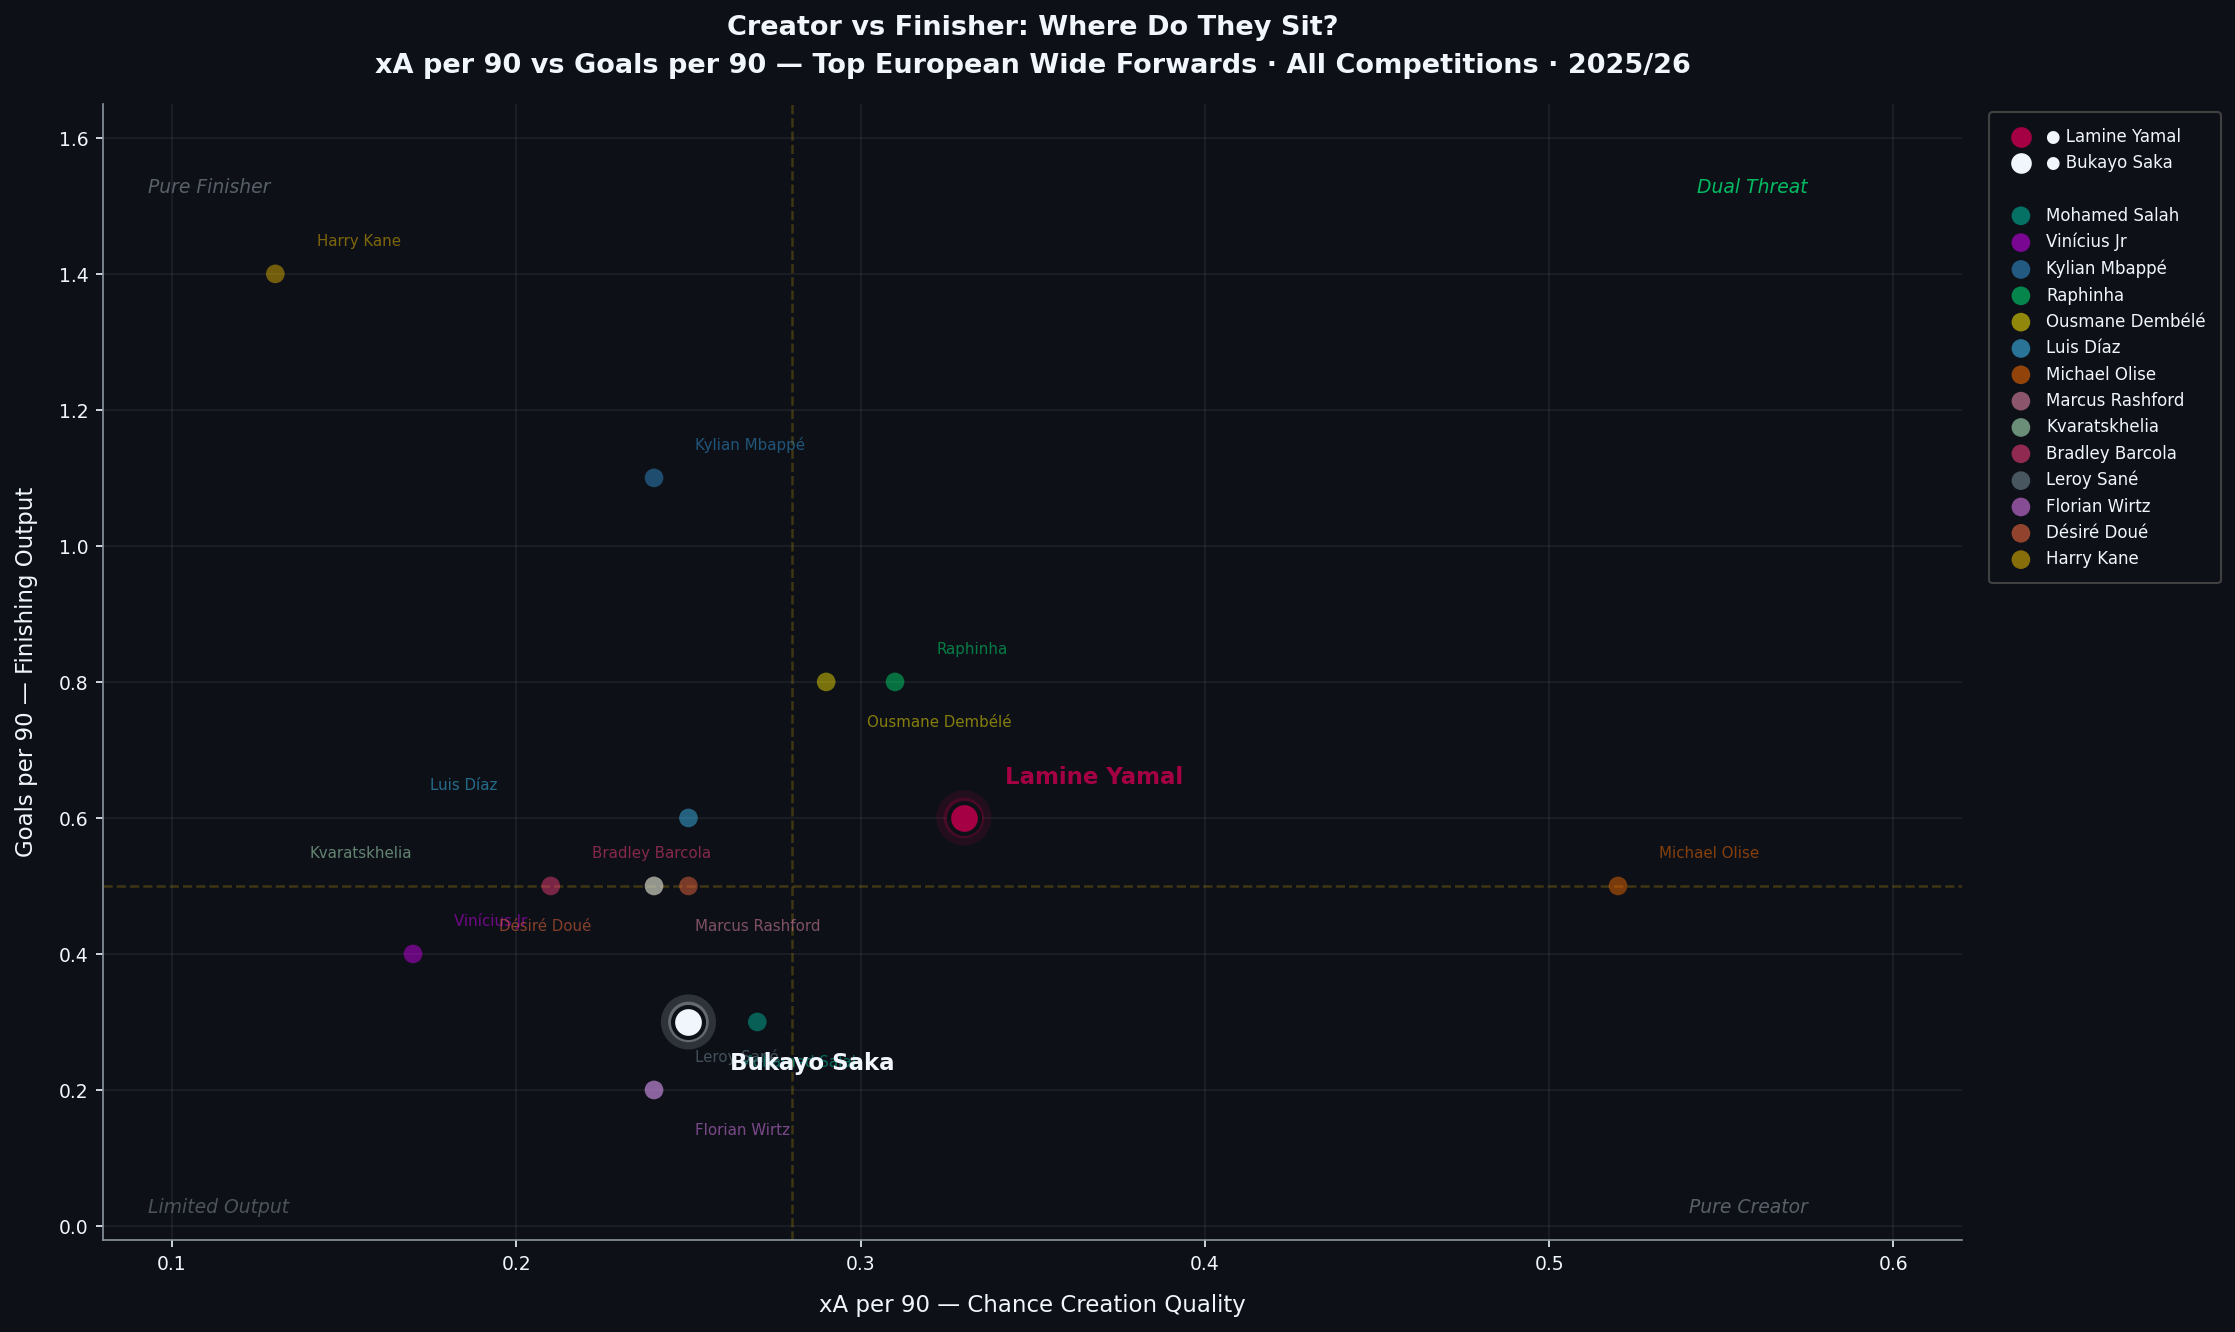

In [1]:
# Chart 07 — Creator vs Finisher Scatter
# Yamal and Saka highlighted with glow halo against 14-player peer group
# All data from barcafutbol_master.csv (25/26 season)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

FOCUS = {'Lamine Yamal', 'Bukayo Saka'}

# Unique colour per player — maximally distinct palette
PLAYER_COLORS = {
    'Lamine Yamal':'#A50044','Bukayo Saka':'#f0f6fc',
    'Kylian Mbappé':'#3498DB','Harry Kane':'#EDBB00',
    'Raphinha':'#00E676','Michael Olise':'#FF6D00',
    'Vinícius Jr':'#D500F9','Mohamed Salah':'#00BFA5',
    'Ousmane Dembélé':'#FFEA00','Luis Díaz':'#40C4FF',
    'Marcus Rashford':'#F48FB1','Kvaratskhelia':'#B9F6CA',
    'Bradley Barcola':'#FF4081','Leroy Sané':'#78909C',
    'Florian Wirtz':'#EA80FC','Désiré Doué':'#FF6E40',
}

# Data: (player, xA/90, Goals/90) — verified from master CSV
scatter_data = peers_2526[['player','xa_90','gls_90']].dropna()

# Label offsets (tuned to avoid overlap)
cf_offsets = {
    'Lamine Yamal':(0.012,0.050),'Bukayo Saka':(0.012,-0.070),
    'Mohamed Salah':(-0.005,-0.065),'Vinícius Jr':(0.012,0.042),
    'Kylian Mbappé':(0.012,0.042),'Raphinha':(0.012,0.042),
    'Ousmane Dembélé':(0.012,-0.065),'Luis Díaz':(-0.075,0.042),
    'Michael Olise':(0.012,0.042),'Marcus Rashford':(0.012,-0.065),
    'Kvaratskhelia':(-0.100,0.042),'Bradley Barcola':(0.012,0.042),
    'Leroy Sané':(0.012,0.042),'Florian Wirtz':(0.012,-0.065),
    'Désiré Doué':(-0.055,-0.065),'Harry Kane':(0.012,0.042),
}

fig, ax = plt.subplots(figsize=(15, 9))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

# Quadrant lines and labels
ax.axvline(x=0.28, color=GOLD, linestyle='--', alpha=0.22, linewidth=1.2)
ax.axhline(y=0.50, color=GOLD, linestyle='--', alpha=0.22, linewidth=1.2)
ax.text(0.575, 1.52, 'Dual Threat',    color='#00E676', fontsize=9, style='italic', ha='right', alpha=0.80)
ax.text(0.093, 1.52, 'Pure Finisher',  color='#8b949e', fontsize=9, style='italic', alpha=0.60)
ax.text(0.575, 0.02, 'Pure Creator',   color='#8b949e', fontsize=9, style='italic', ha='right', alpha=0.60)
ax.text(0.093, 0.02, 'Limited Output', color='#8b949e', fontsize=9, style='italic', alpha=0.50)

# Peer players first (behind, faded)
for _, row in scatter_data.iterrows():
    name = row['player']
    if name in FOCUS: continue
    x, y = row['xa_90'], row['gls_90']
    c = PLAYER_COLORS.get(name, '#888888')
    ax.scatter(x, y, s=80, color=c, alpha=0.45, zorder=3, edgecolors='none')
    ox, oy = cf_offsets.get(name, (0.01, 0.03))
    ax.annotate(name, xy=(x, y), xytext=(x+ox, y+oy),
                color=c, alpha=0.50, fontsize=7.2, zorder=4)

# Focus players — triple glow halo
for name in ('Lamine Yamal', 'Bukayo Saka'):
    row = scatter_data[scatter_data['player']==name].iloc[0]
    x, y, c = row['xa_90'], row['gls_90'], PLAYER_COLORS[name]
    ax.scatter(x, y, s=700, color=c, alpha=0.15, zorder=5, edgecolors='none')
    ax.scatter(x, y, s=380, color=c, alpha=0.28, zorder=6, edgecolors='none')
    ax.scatter(x, y, s=220, color=c, alpha=1.0,  zorder=7, edgecolors=BG, linewidth=2.0)
    ox, oy = cf_offsets[name]
    ax.annotate(name, xy=(x, y), xytext=(x+ox, y+oy),
                color=c, fontsize=11, fontweight='bold', zorder=8)

# Legend
handles = [plt.scatter([],[],s=130,color=PLAYER_COLORS[n],edgecolors=BG,
                        linewidth=1.5,label=f'● {n}')
           for n in ('Lamine Yamal','Bukayo Saka')]
handles += [plt.Line2D([0],[0],color='none',label='')]
handles += [plt.scatter([],[],s=80,color=PLAYER_COLORS.get(row['player'],'#888'),
                         alpha=0.55,edgecolors='none',label=row['player'])
            for _,row in scatter_data.iterrows() if row['player'] not in FOCUS]

ax.legend(handles=handles, loc='upper left', bbox_to_anchor=(1.01,1.0),
          fontsize=8.0, facecolor='#0d1117', edgecolor='#444',
          labelcolor=WHITE, framealpha=0.96,
          handletextpad=0.5, borderpad=0.9, labelspacing=0.50)

ax.set_xlabel('xA per 90 — Chance Creation Quality', color=WHITE, fontsize=11, labelpad=10)
ax.set_ylabel('Goals per 90 — Finishing Output',       color=WHITE, fontsize=11, labelpad=10)
ax.set_xlim(0.08, 0.62); ax.set_ylim(-0.02, 1.65)
ax.tick_params(colors=WHITE, labelsize=9)
ax.spines['bottom'].set_color(GRAY); ax.spines['left'].set_color(GRAY)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.07, color=WHITE)
ax.set_title('Creator vs Finisher: Where Do They Sit?\n'
             'xA per 90 vs Goals per 90 — Top European Wide Forwards · All Competitions · 2025/26',
             color=WHITE, fontsize=13, fontweight='bold', pad=15, linespacing=1.6)
plt.tight_layout()
plt.show()

---
## Chart 08 · xG vs Goals — Who Converts Above Expectation?

**The diagonal line = xG equals Goals.** Above it: scoring more than shot quality predicts.
Below it: shots are there, goals are not arriving.

| Player | xG/90 | Goals/90 | Difference |
|--------|-------|----------|------------|
| Lamine Yamal | 0.41 | 0.60 | **+0.19 OVER** |
| Bukayo Saka | 0.28 | 0.30 | +0.02 (on the line) |
| Mohamed Salah | 0.38 | 0.30 | -0.08 UNDER |

**Key insight:** Yamal consistently converts above expectation (+0.19) — a pattern
sustained across two seasons that is not luck. Saka tracks the model almost exactly,
season after season. Salah sits below the line at 33 — his xG remains high
but the conversion is declining. The diagonal tells you what the highlights don't.

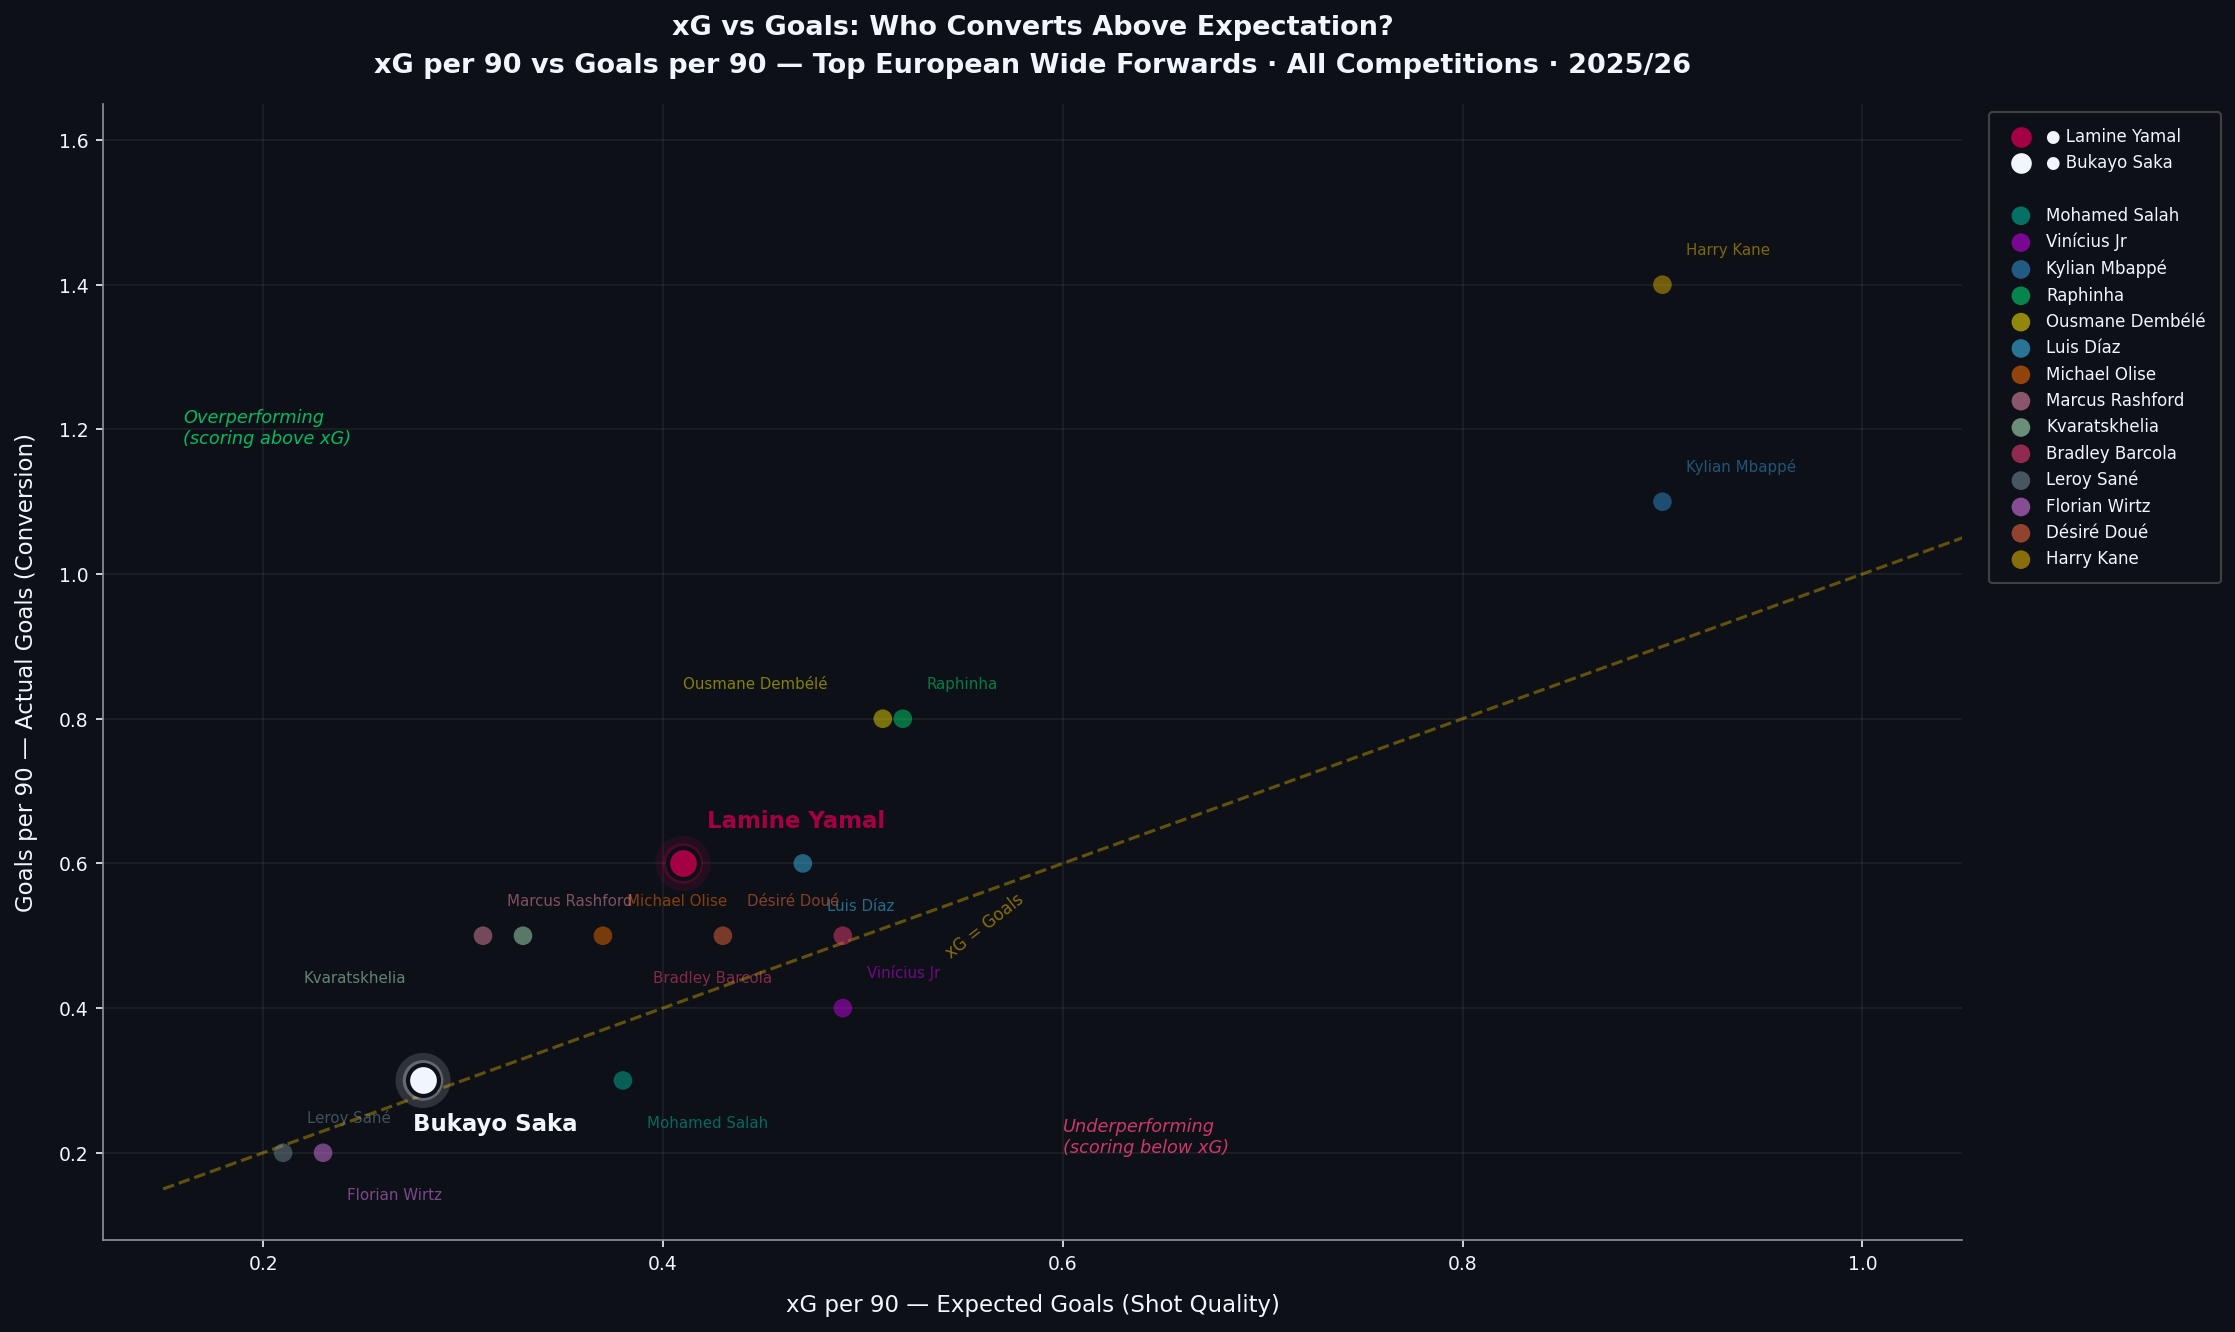

In [1]:
# Chart 08 — xG vs Goals: Overperformance Scatter
# The diagonal line = expected equals actual
# Above line = converting better than shot quality predicts

scatter_xg = peers_2526[['player','xg_90','gls_90']].dropna()

xg_offsets = {
    'Lamine Yamal':(0.012,0.050),'Bukayo Saka':(-0.005,-0.070),
    'Mohamed Salah':(0.012,-0.065),'Vinícius Jr':(0.012,0.042),
    'Kylian Mbappé':(0.012,0.042),'Raphinha':(0.012,0.042),
    'Ousmane Dembélé':(-0.100,0.042),'Luis Díaz':(0.012,-0.065),
    'Michael Olise':(0.012,0.042),'Marcus Rashford':(0.012,0.042),
    'Kvaratskhelia':(-0.110,-0.065),'Bradley Barcola':(-0.095,-0.065),
    'Leroy Sané':(0.012,0.042),'Florian Wirtz':(0.012,-0.065),
    'Désiré Doué':(0.012,0.042),'Harry Kane':(0.012,0.042),
}

fig, ax = plt.subplots(figsize=(15, 9))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

# Diagonal reference line
xl = np.linspace(0.15, 1.05, 300)
ax.plot(xl, xl, color=GOLD, linewidth=1.5, linestyle='--', alpha=0.38, zorder=2)
ax.text(0.54, 0.47, 'xG = Goals', color=GOLD, fontsize=8, alpha=0.55, rotation=38)
ax.text(0.16, 1.18, 'Overperforming\n(scoring above xG)',
        color='#00E676', fontsize=8.5, style='italic', alpha=0.80)
ax.text(0.60, 0.20, 'Underperforming\n(scoring below xG)',
        color='#FF4081', fontsize=8.5, style='italic', alpha=0.80)

# Peers (faded)
for _, row in scatter_xg.iterrows():
    name = row['player']
    if name in FOCUS: continue
    x, y = row['xg_90'], row['gls_90']
    c = PLAYER_COLORS.get(name, '#888888')
    ax.scatter(x, y, s=80, color=c, alpha=0.45, zorder=3, edgecolors='none')
    ox, oy = xg_offsets.get(name, (0.01, 0.03))
    ax.annotate(name, xy=(x, y), xytext=(x+ox, y+oy),
                color=c, alpha=0.50, fontsize=7.2, zorder=4)

# Focus — halo
for name in ('Lamine Yamal', 'Bukayo Saka'):
    row = scatter_xg[scatter_xg['player']==name].iloc[0]
    x, y, c = row['xg_90'], row['gls_90'], PLAYER_COLORS[name]
    ax.scatter(x, y, s=700, color=c, alpha=0.15, zorder=5, edgecolors='none')
    ax.scatter(x, y, s=380, color=c, alpha=0.28, zorder=6, edgecolors='none')
    ax.scatter(x, y, s=220, color=c, alpha=1.0,  zorder=7, edgecolors=BG, linewidth=2.0)
    ox, oy = xg_offsets[name]
    ax.annotate(name, xy=(x, y), xytext=(x+ox, y+oy),
                color=c, fontsize=11, fontweight='bold', zorder=8)

# Legend (with xG line)
handles = [plt.scatter([],[],s=130,color=PLAYER_COLORS[n],edgecolors=BG,
                        linewidth=1.5,label=f'● {n}')
           for n in ('Lamine Yamal','Bukayo Saka')]
handles += [plt.Line2D([0],[0],color='none',label='')]
handles += [plt.scatter([],[],s=80,color=PLAYER_COLORS.get(row['player'],'#888'),
                         alpha=0.55,edgecolors='none',label=row['player'])
            for _,row in scatter_xg.iterrows() if row['player'] not in FOCUS]
handles += [plt.Line2D([0],[0],color=GOLD,linewidth=1.5,
                        linestyle='--',alpha=0.7,label='xG = Goals line')]

ax.legend(handles=handles, loc='upper left', bbox_to_anchor=(1.01,1.0),
          fontsize=8.0, facecolor='#0d1117', edgecolor='#444',
          labelcolor=WHITE, framealpha=0.96,
          handletextpad=0.5, borderpad=0.9, labelspacing=0.50)

ax.set_xlabel('xG per 90 — Expected Goals (Shot Quality)', color=WHITE, fontsize=11, labelpad=10)
ax.set_ylabel('Goals per 90 — Actual Goals (Conversion)',   color=WHITE, fontsize=11, labelpad=10)
ax.set_xlim(0.12, 1.05); ax.set_ylim(0.08, 1.65)
ax.tick_params(colors=WHITE, labelsize=9)
ax.spines['bottom'].set_color(GRAY); ax.spines['left'].set_color(GRAY)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.07, color=WHITE)
ax.set_title('xG vs Goals: Who Converts Above Expectation?\n'
             'xG per 90 vs Goals per 90 — Top European Wide Forwards · All Competitions · 2025/26',
             color=WHITE, fontsize=13, fontweight='bold', pad=15, linespacing=1.6)
plt.tight_layout()
plt.show()

---
## Summary

All 8 charts built and rendered inline.

| Chart | File | Key Finding |
|-------|------|-------------|
| 01 Career Arc | `outputs/01_career_arc.png` | Yamal at 18 = Saka's peak at 23 |
| 02 Full Profile | `outputs/02_pizza_dual.png` | Yamal attacks more; Saka crosses better |
| 03 Attacking | `outputs/03_radar_attacking.png` | Yamal 92nd pct shots; Saka more precise |
| 04 Possession | `outputs/04_radar_possession.png` | Yamal creates more; Saka delivers better |
| 05 Defensive | `outputs/05_radar_defending.png` | Saka 88th pct discipline; Yamal declining |
| 06 Head to Head | `outputs/06_head_to_head.png` | Yamal wins 7/10; Saka wins precision metrics |
| 07 Scatter CF | `outputs/07_scatter_cf.png` | Yamal in dual-threat territory at 18 |
| 08 Scatter xG | `outputs/08_scatter_xg.png` | Yamal +0.19 over xG; Saka exactly on line |

---
*Data: Sofascore · BarcaFutbol Analytics · HackrLife Media LLC · April 2026*
*Full article: "What Do You Get When You Pit Lamine Against Saka?" — barcafutbol.com*

In [1]:
# All charts rendered. PNG files saved to outputs/ directory.
import os
saved = [f for f in os.listdir('outputs') if f.endswith('.png')]
print(f"Charts saved to outputs/: {len(saved)} files")
for f in sorted(saved):
    print(f"  {f}")

Charts saved to outputs/: 8 files
  01_career_arc.png
  02_pizza_dual.png
  03_radar_attacking.png
  04_radar_possession.png
  05_radar_defending.png
  06_head_to_head.png
  07_scatter_cf.png
  08_scatter_xg.png
